<a href="https://colab.research.google.com/github/JanuNandhini/24ADI003-ex-7-24BAD041/blob/main/gmm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

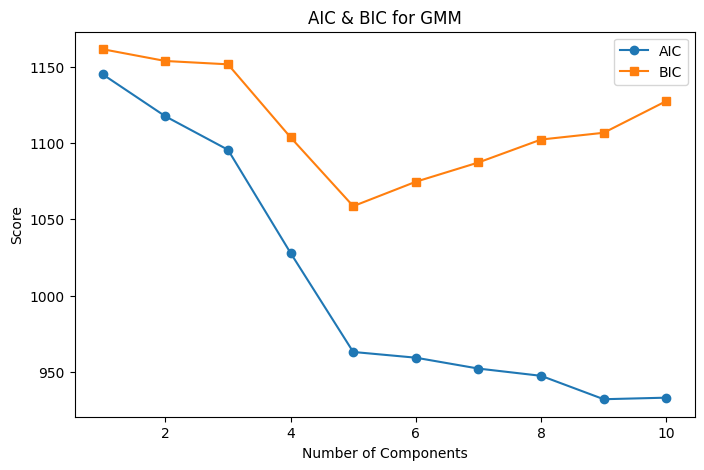


Evaluation Metrics:
Log-Likelihood: -2.262502621973241
AIC: 963.0010487892964
BIC: 1058.6522524191894
Silhouette Score (GMM): 0.5536892843811245
Silhouette Score (K-Means): 0.5546571631111091


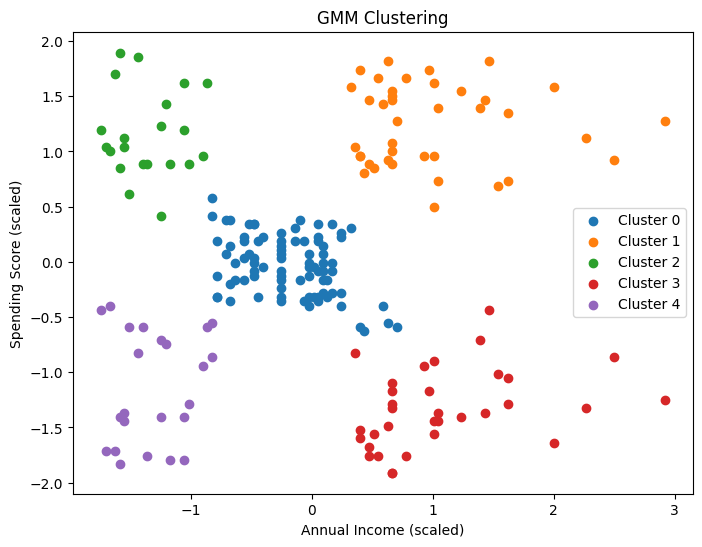

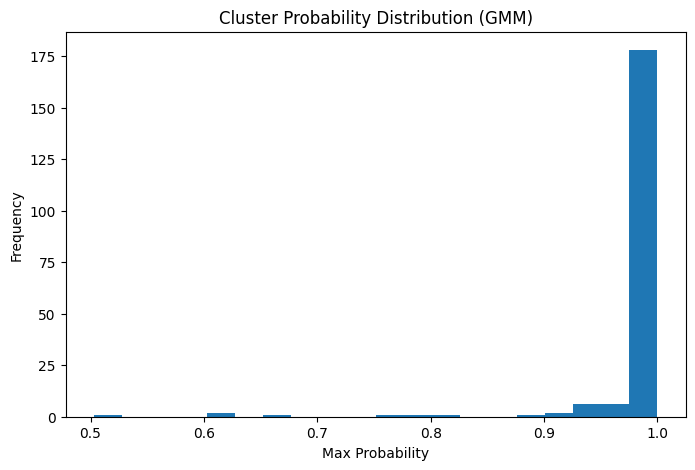

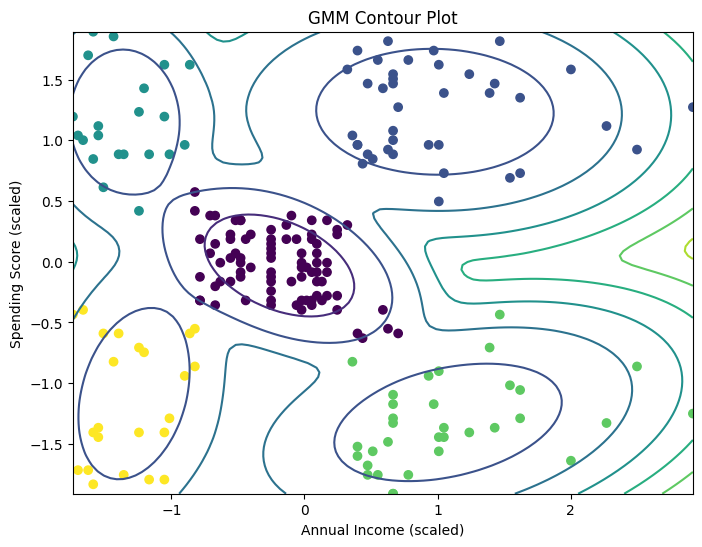

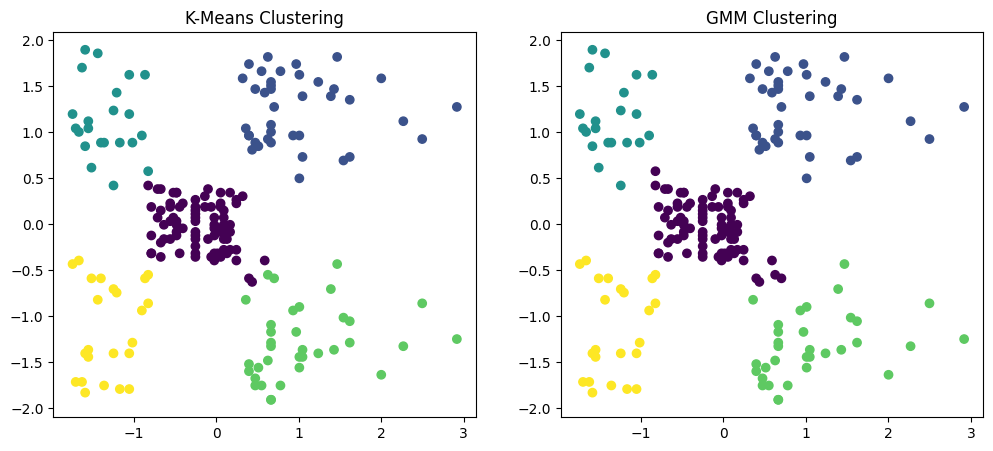


GMM Cluster Means:

             Annual Income (k$)  Spending Score (1-100)        Age
GMM_Cluster                                                       
0                     55.642857               49.369048  42.714286
1                     86.538462               82.128205  32.692308
2                     25.095238               80.047619  25.333333
3                     88.818182               16.000000  40.454545
4                     26.304348               20.913043  45.217391


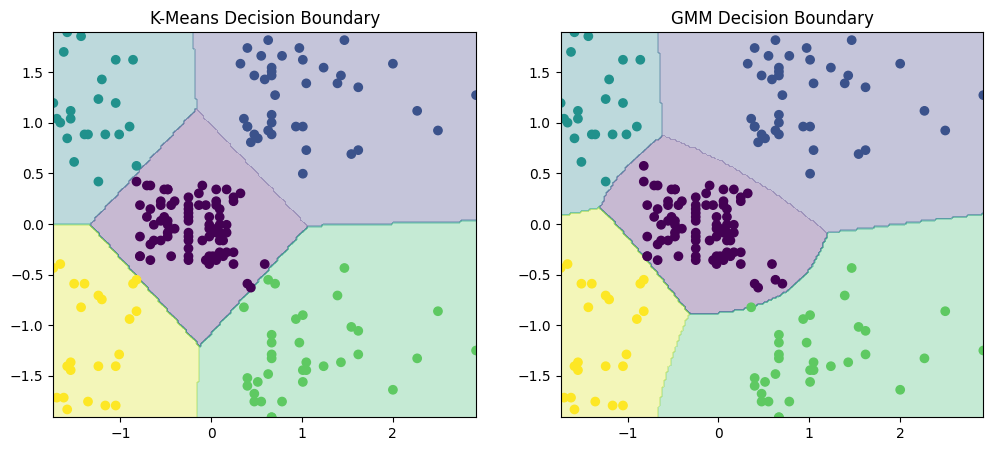

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
df = pd.read_csv("/content/Mall_Customers.csv")


df.dropna(inplace=True)
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
n_components = range(1, 11)


aic = []
bic = []
for n in n_components:
    gmm = GaussianMixture(n_components=n, random_state=42)
    gmm.fit(X_scaled)
    aic.append(gmm.aic(X_scaled))
    bic.append(gmm.bic(X_scaled))
plt.figure(figsize=(8,5))
plt.plot(n_components, aic, marker='o', label='AIC')
plt.plot(n_components, bic, marker='s', label='BIC')
plt.xlabel("Number of Components")
plt.ylabel("Score")
plt.title("AIC & BIC for GMM")
plt.legend()
plt.show()


optimal_k = 5
gmm = GaussianMixture(n_components=optimal_k, random_state=42)
gmm.fit(X_scaled)
probs = gmm.predict_proba(X_scaled)
clusters_gmm = np.argmax(probs, axis=1)
df['GMM_Cluster'] = clusters_gmm
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters_kmeans = kmeans.fit_predict(X_scaled)
df['KMeans_Cluster'] = clusters_kmeans
print("\nEvaluation Metrics:")
print("Log-Likelihood:", gmm.score(X_scaled))
print("AIC:", gmm.aic(X_scaled))
print("BIC:", gmm.bic(X_scaled))


sil_gmm = silhouette_score(X_scaled, clusters_gmm)
sil_kmeans = silhouette_score(X_scaled, clusters_kmeans)
print("Silhouette Score (GMM):", sil_gmm)
print("Silhouette Score (K-Means):", sil_kmeans)
plt.figure(figsize=(8,6))
for i in range(optimal_k):
    plt.scatter(X_scaled[clusters_gmm == i, 0], X_scaled[clusters_gmm == i, 1], label=f'Cluster {i}')
plt.title("GMM Clustering")
plt.xlabel("Annual Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.legend()
plt.show()
plt.figure(figsize=(8,5))
plt.hist(probs.max(axis=1), bins=20)
plt.title("Cluster Probability Distribution (GMM)")
plt.xlabel("Max Probability")
plt.ylabel("Frequency")
plt.show()



x = np.linspace(X_scaled[:,0].min(), X_scaled[:,0].max(), 100)
y = np.linspace(X_scaled[:,1].min(), X_scaled[:,1].max(), 100)
X_grid, Y_grid = np.meshgrid(x, y)
XX = np.array([X_grid.ravel(), Y_grid.ravel()]).T
Z = -gmm.score_samples(XX)
Z = Z.reshape(X_grid.shape)
plt.figure(figsize=(8,6))
plt.contour(X_grid, Y_grid, Z)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=clusters_gmm)
plt.title("GMM Contour Plot")
plt.xlabel("Annual Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.show()
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=clusters_kmeans)
plt.title("K-Means Clustering")
plt.subplot(1,2,2)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=clusters_gmm)
plt.title("GMM Clustering")
plt.show()
print("\nGMM Cluster Means:\n")
print(df.groupby('GMM_Cluster')[['Annual Income (k$)', 'Spending Score (1-100)', 'Age']].mean())



x = np.linspace(X_scaled[:,0].min(), X_scaled[:,0].max(), 200)
y = np.linspace(X_scaled[:,1].min(), X_scaled[:,1].max(), 200)
xx, yy = np.meshgrid(x, y)
grid = np.c_[xx.ravel(), yy.ravel()]
Z_kmeans = kmeans.predict(grid).reshape(xx.shape)
Z_gmm = gmm.predict(grid).reshape(xx.shape)
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.contourf(xx, yy, Z_kmeans, alpha=0.3)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=clusters_kmeans)
plt.title("K-Means Decision Boundary")
plt.subplot(1,2,2)
plt.contourf(xx, yy, Z_gmm, alpha=0.3)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=clusters_gmm)
plt.title("GMM Decision Boundary")
plt.show()